## 1. Numerical Variables

**Step 1 - Concept**

For a numerical column, "understanding" it means knowing where most values sit (mean, median), how spread out they are (standard deviation, range), and whether the distribution is symmetric or leaning to one side (skewness). Mean and median can disagree - when they do, that's usually a sign the data is skewed.

**Step 2 - Demonstrate the Concept**

**Simple example:** For the numbers 2, 3, 3, 4, 100 - the mean is pulled way up to 22.4 by the single large value, but the median stays at 3. That mismatch tells you there's an outlier or skew.

**Real-world example:** In a company's salary data, most employees earn a moderate salary, but a few executives earn far more - so the average salary looks higher than what a "typical" employee actually earns.

**Business example:** A telecom company looking at MonthlyCharges needs to know if most customers pay near the average, or if there's a small group paying very high bills that's dragging the average up - that changes what a "typical customer" pricing strategy should look like.

**AI/ML use case:** Many ML algorithms (like linear regression or k-means) assume features are roughly symmetric. If a feature like TotalCharges is heavily skewed, the model can end up overly influenced by a few large values unless the skew is corrected (e.g. with a log transform).

**Why it matters:** These summary numbers are the foundation for every later step - if I don't know a column is skewed now, I might misinterpret a chart later, or feed a badly-shaped feature straight into a model.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("custumer.csv")
df.shapenum_cols = ["Age", "TenureYears", "MonthlyCharges", "TotalCharges", "SupportCalls"]
df[num_cols].describe()

C:\Users\HP\AppData\Local\Temp\ipykernel_28272\1357463989.py:7: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.shapenum_cols = ["Age", "TenureYears", "MonthlyCharges", "TotalCharges", "SupportCalls"]


,Age,TenureYears,MonthlyCharges,TotalCharges,SupportCalls
count,4969.000000,5020.000000,4970.000000,4969.000000,5020.000000
mean,43.328034,4.911753,69.480559,4126.251849,2.105777
std,14.762282,3.137479,28.678515,3237.099088,1.630602
min,18.000000,0.000000,20.020000,72.450000,0.000000
25%,31.000000,2.000000,44.602500,1440.880000,1.000000
50%,43.000000,5.000000,69.285000,3355.920000,2.000000
75%,56.000000,8.000000,93.770000,6068.800000,3.000000
max,69.000000,10.000000,119.970000,14603.300000,9.000000


In [3]:
summary = pd.DataFrame({
    "mean": df[num_cols].mean(),
    "median": df[num_cols].median(),
    "std_dev": df[num_cols].std(),
    "variance": df[num_cols].var(),
    "skewness": df[num_cols].skew(),
    "kurtosis": df[num_cols].kurtosis()
}).round(2)
summary

,mean,median,std_dev,variance,skewness,kurtosis
Age,43.33,43.00,14.76,217.92,0.01,-1.21
TenureYears,4.91,5.00,3.14,9.84,0.03,-1.21
MonthlyCharges,69.48,69.28,28.68,822.46,0.04,-1.18
TotalCharges,4126.25,3355.92,3237.10,10478810.51,0.88,0.05
SupportCalls,2.11,2.00,1.63,2.66,1.15,2.06


**Interpretation:**

Age, TenureYears, and MonthlyCharges all have skewness close to 0 - they're roughly symmetric, mean and median are close.
TotalCharges has skewness of 0.88 - moderately right-skewed. Makes sense, since customers with long tenure accumulate very high total charges, pulling the tail right.
SupportCalls has skewness of 1.15 and kurtosis of 2.06 - right-skewed with a sharper peak. Most customers call support rarely, but a smaller group calls often.

**Insight:** TotalCharges and SupportCalls are the two columns to treat carefully before modeling - either through a log transform or by being aware that their mean is not fully representative of a "typical" customer.

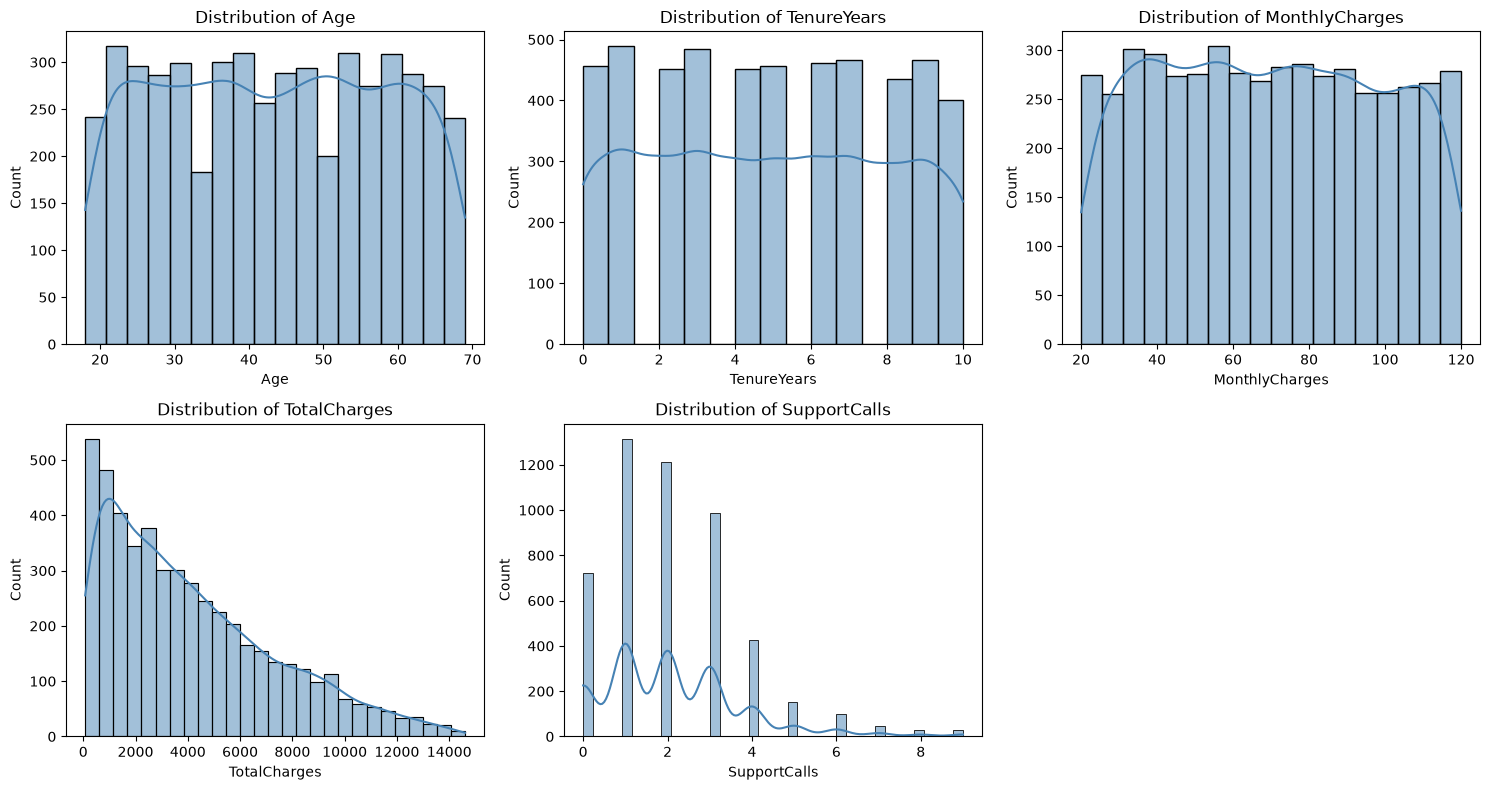

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

**Output:** histograms with KDE overlay for each of the 5 numerical columns.

**Interpretation:** The histograms confirm the skewness numbers - Age, TenureYears, and MonthlyCharges look fairly even/spread out, while TotalCharges and SupportCalls clearly lean to the right with a longer tail on the high end.

**Insight:** This visual check matches the statistics exactly, which is a good way to double-check that the skewness number isn't misleading on its own.

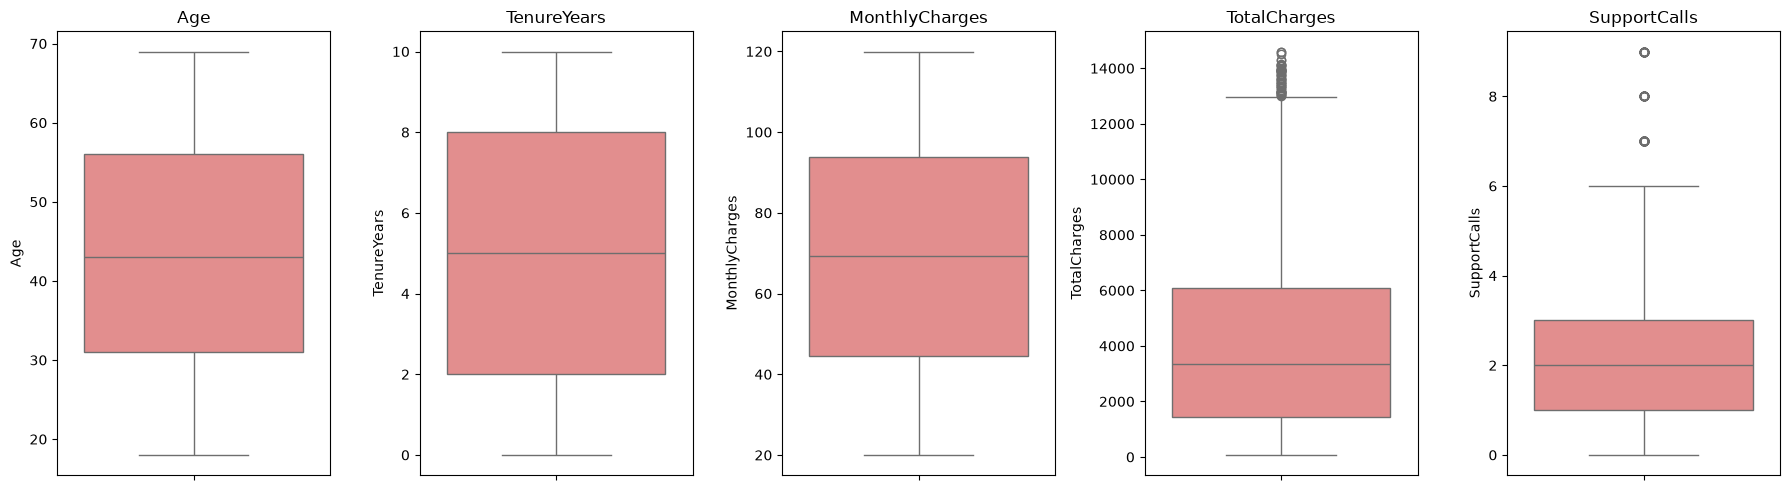

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

**Output:** box plots for each numerical column.

**Interpretation:** The box plots for Age, TenureYears, and MonthlyCharges are fairly balanced with short whiskers - no major outliers. TotalCharges and SupportCalls both show points above the upper whisker, meaning there are a number of customers with unusually high total billing or unusually frequent support calls, consistent with the right-skew seen earlier.

**AI/ML Relevance:** These same points flagged as "outliers" here need proper investigation in Notebook 7 - Outlier Analysis - before deciding whether to cap, transform, or keep them, since a support-heavy customer might actually be a strong churn signal, not a data error.

## 2. Categorical Variables
**Step 1 - Concept**

For a categorical column, understanding it means knowing what categories exist, how many rows fall into each one, and whether any category is rare or dominant. This matters because a model can struggle to learn from a category that appears in only a handful of rows.

**Step 2 - Demonstrate the Concept**

**Simple example:** In a class of 30 students, if "Blood Group" has categories A, B, AB, O - counting how many students fall into each tells you the class composition at a glance.

**Real-world example:** A survey asking "Which city do you live in?" - if 90% of responses come from one city and the rest are scattered across 10 others, that's an imbalance worth noting before drawing conclusions about "typical" respondents.

**Business example:** A telecom company checking ContractType finds that most customers are on Month-to-month plans - that's directly useful for marketing, since month-to-month customers are usually the easiest to lose to a competitor.

**AI/ML use case:** If Churn (the target variable) has 90% "No" and only 10% "Yes", a model can get 90% accuracy just by always predicting "No" - which looks good on paper but is actually useless. Checking category balance early prevents this kind of misleading result later.

**Why it matters:** Category counts tell me which variables are balanced and safe to use as-is, and which ones (like a rare category or an imbalanced target) need special handling before modeling.

In [7]:
cat_cols = ["Gender", "ContractType", "InternetService", "PaymentMethod",
            "SeniorCitizen", "StreamingService", "PaperlessBilling", "Churn"]

for col in cat_cols:
    print(f"--- {col} ---")
    counts = df[col].value_counts()
    percent = df[col].value_counts(normalize=True).round(3) * 100
    print(pd.DataFrame({"count": counts, "percent": percent}))
    print()

--- Gender ---
        count  percent
Gender                
Male     2587     51.5
Female   2433     48.5

--- ContractType ---
                count  percent
ContractType                  
Month-to-month   2236     44.5
Two year         1570     31.3
One year         1214     24.2

--- InternetService ---
                 count  percent
InternetService                
DSL               2015     40.1
Fiber optic       2006     40.0
No                 999     19.9

--- PaymentMethod ---
                  count  percent
PaymentMethod                   
Electronic check   1286     25.6
Credit card        1281     25.5
Mailed check       1235     24.6
Bank transfer      1218     24.3

--- SeniorCitizen ---
               count  percent
SeniorCitizen                
No              4118     82.0
Yes              902     18.0

--- StreamingService ---
                  count  percent
StreamingService                
Yes                2561     51.0
No                 2459     49.0

--- Pape

**Interpretation:**

Gender, InternetService, PaymentMethod, and StreamingService are all fairly balanced across their categories - no category dominates.
SeniorCitizen is imbalanced - only 18% of customers are senior citizens.
ContractType is skewed toward Month-to-month (44.5%), with One year being the smallest group (24.2%).
Churn, the target variable, is imbalanced - 71% did not churn, 29% did churn.

**Insight:** The Churn imbalance is the most important finding here, since it's the target variable. A model trained on this without any adjustment could lean toward predicting "No" too often. This needs to be handled carefully in the modeling stage (e.g. class weighting or resampling).

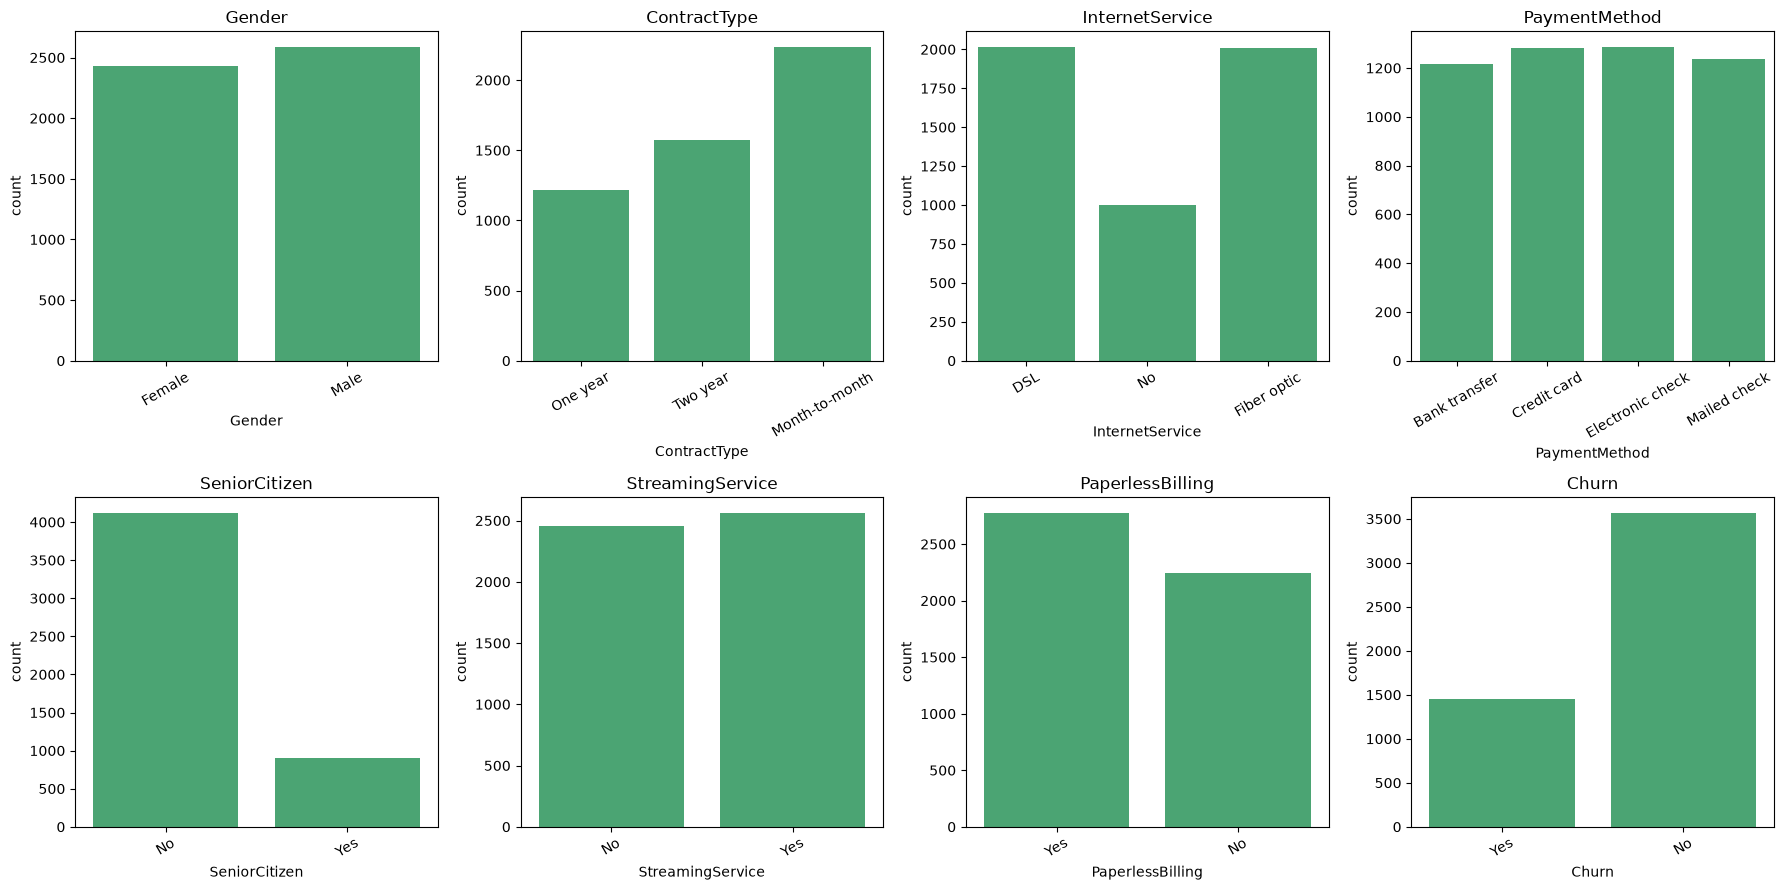

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i], color="mediumseagreen")
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Output:** count plots (bar charts) for all 8 categorical columns.

**Interpretation:** The count plots make the imbalance in SeniorCitizen and Churn visually obvious - both have one bar clearly taller than the other. The rest of the categorical columns show fairly even bars.

**AI/ML Relevance:** Since Churn is the target, its imbalance (visible here) is something I'll need to specifically address in Notebook 10 (Target Variable Analysis) and again before model training - this notebook is just flagging it as an observation for now.